# PulseIA — Classificador de risco textual

Fase 2 • Grupo PulseIA

Este exercício transforma frases simuladas em vetores TF-IDF e treina uma Regressão Logística para distinguir `alto risco` e `baixo risco`. Os rótulos foram definidos para a atividade, sem validação clínica. Não correspondem a diagnósticos nem autorizam decisões de atendimento.

Execute as células em ordem. A base numérica da Fase 1 permanece como referência de governança; não usamos seu alvo artificial para rotular estas frases. As imagens e os textos institucionais da Fase 1 não são dados de treinamento deste classificador.

In [1]:
from pathlib import Path
import sys, json, hashlib, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split, StratifiedGroupKFold, cross_validate, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "fase2/data/frases_risco.csv").exists())
SAIDA = RAIZ / "fase2/outputs"
SAIDA.mkdir(exist_ok=True)
SEED = 42
CLASSES = ["baixo risco", "alto risco"]
dados = pd.read_csv(RAIZ / "fase2/data/frases_risco.csv")
assert not dados.isna().any().any()
assert set(dados.situacao) == set(CLASSES)
assert not dados.frase.str.lower().str.strip().duplicated().any()
assert dados.groupby("grupo").situacao.nunique().eq(1).all()
display(dados.head())

,frase,situacao,grupo
0,Dor no peito começou de repente e estou suando...,alto risco,A01
1,Sinto pressão no tórax acompanhada de suor gel...,alto risco,A01
2,Estou sem ar mesmo sentado e não consigo falar...,alto risco,A02
3,A respiração ficou difícil em repouso e mal co...,alto risco,A02
4,Desmaiei durante a caminhada e continuo muito ...,alto risco,A03


## 1. Composição e limites da base

São 240 frases simuladas em português, em 120 cenários com duas paráfrases cada: 120 frases por classe. A ampliação acrescentou negações, contraste, relatos sobre outras pessoas, escrita informal e sintomas com intensidades diferentes. Os 80 exemplos originais foram preservados.

O equilíbrio é artificial. `grupo` identifica paráfrases e não entra no modelo. Cenários diferentes ainda compartilham expressões; 240 frases não equivalem a 240 observações independentes. Os rótulos foram escritos para a atividade e não passaram por revisão clínica independente.

In [2]:
perfil = dados.groupby("situacao").agg(frases=("frase", "size"), grupos=("grupo", "nunique"))
perfil["percentual"] = perfil.frases / len(dados) * 100
display(perfil)
dados["palavras"] = dados.frase.str.split().str.len()
display(dados.groupby("situacao").palavras.agg(["min", "median", "mean", "max"]))
print("Duplicatas exatas:", dados.frase.duplicated().sum())

,frases,grupos,percentual
situacao,,,
alto risco,120,60,50.0
baixo risco,120,60,50.0


,min,median,mean,max
situacao,,,,
alto risco,8,12.0,11.933333,17
baixo risco,7,14.0,13.425000,19


Duplicatas exatas: 0


## 2. Partições fixadas antes de avaliar a revisão

O manifesto `data/particoes.csv` mantém os 64 exemplos do treino original e acrescenta 120, totalizando 184 frases. Os 16 exemplos do teste antigo ficam em `regressao`: seus erros já orientaram melhorias e por isso não são mais um teste novo. Os 40 exemplos dos grupos A51–A60 e B51–B60 são o teste reservado da revisão.

As partições foram fixadas antes da execução desta avaliação. Não redividimos os dados para buscar um resultado melhor. Duas paráfrases ficam sempre juntas. Todos os exemplos ainda têm a mesma origem de autoria sintética; este teste é interno, não validação externa.

In [3]:
particoes = pd.read_csv(RAIZ / "fase2/data/particoes.csv")
assert not particoes.grupo.duplicated().any()
assert set(particoes.grupo) == set(dados.grupo)
dados = dados.merge(particoes, on="grupo", validate="many_to_one")
treino = dados[dados.conjunto == "treino"].copy()
teste = dados[dados.conjunto == "teste"].copy()
regressao = dados[dados.conjunto == "regressao"].copy()
assert set(treino.grupo).isdisjoint(teste.grupo)
assert set(treino.grupo).isdisjoint(regressao.grupo)
assert set(teste.grupo).isdisjoint(regressao.grupo)
assert (len(treino), len(teste), len(regressao)) == (184, 40, 16)
display(pd.crosstab(dados.situacao, dados.conjunto))
dados[["frase", "situacao", "grupo", "conjunto"]].to_csv(SAIDA / "divisao_dados.csv", index=False)

conjunto,regressao,teste,treino
situacao,,,
alto risco,8,20,92
baixo risco,8,20,92


## 3. Comparação de configurações somente no treino

Mantemos TF-IDF e Regressão Logística. Comparamos unigramas/bigramas com unigramas/bigramas/trigramas e duas intensidades de regularização (C=1 e C=4). A validação cruzada tem quatro divisões por cenário e escolhe o maior F1 macro, equilibrando as duas classes. Não escolhemos configurações com os resultados do teste final.

O TF-IDF é ajustado dentro de cada divisão do Pipeline. Palavras de negação são mantidas. Trigramas podem representar expressões mais longas, mas não garantem compreensão de contexto. Os valores da validação usados na seleção podem ser otimistas; a avaliação principal é a partição reservada.

Para comparar a revisão com a versão anterior no mesmo teste novo, também treinamos a configuração original nos mesmos 64 exemplos originais de treino.

In [4]:
def criar_modelo():
    return Pipeline([
        ("tfidf", TfidfVectorizer(strip_accents="unicode", lowercase=True, ngram_range=(1, 2))),
        ("classificador", LogisticRegression(max_iter=1000, random_state=SEED))
    ])

cv = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=SEED)
busca = GridSearchCV(criar_modelo(), {
    "tfidf__ngram_range": [(1, 2), (1, 3)],
    "classificador__C": [1.0, 4.0]
}, cv=cv, scoring={"acuracia": "accuracy", "f1_macro": "f1_macro"}, refit="f1_macro")
busca.fit(treino.frase, treino.situacao, groups=treino.grupo)
modelo = busca.best_estimator_
comparacao_cv = pd.DataFrame(busca.cv_results_)
display(comparacao_cv[["params", "mean_test_acuracia", "mean_test_f1_macro", "std_test_f1_macro"]])
comparacao_cv.to_csv(SAIDA / "comparacao_cv.csv", index=False)
i = busca.best_index_
cv_resultados = {"test_" + metrica: np.array([busca.cv_results_[f"split{k}_test_{metrica}"][i] for k in range(4)])
                 for metrica in ("acuracia", "f1_macro")}
print("Configuração selecionada:", busca.best_params_)
originais = treino[treino.grupo.str[1:].astype(int) <= 20]
assert len(originais) == 64
modelo_anterior = criar_modelo().fit(originais.frase, originais.situacao)
print("Vocabulário do treino ampliado:", len(modelo.named_steps["tfidf"].vocabulary_))

,params,mean_test_acuracia,mean_test_f1_macro,std_test_f1_macro
0,"{'classificador__C': 1.0, 'tfidf__ngram_range'...",0.913043,0.913018,0.050994
1,"{'classificador__C': 1.0, 'tfidf__ngram_range'...",0.907609,0.907596,0.054079
2,"{'classificador__C': 4.0, 'tfidf__ngram_range'...",0.918478,0.918424,0.049525
3,"{'classificador__C': 4.0, 'tfidf__ngram_range'...",0.913043,0.913002,0.053250


Configuração selecionada: {'classificador__C': 4.0, 'tfidf__ngram_range': (1, 2)}
Vocabulário do treino ampliado: 1945


## 4. Avaliação no teste reservado

Calculamos acurácia, precisão, recall e F1 por classe e mostramos cada erro. O DummyClassifier é a referência mínima. Comparamos também o modelo treinado em 64 exemplos com o modelo revisado no mesmo teste novo de 40 frases. Essa comparação é mais informativa que comparar porcentagens obtidas em testes diferentes.

O teste tem 20 cenários independentes, com duas paráfrases cada. Um erro altera a acurácia em 2,5 pontos percentuais; as métricas continuam sensíveis à composição dos exemplos. Falsos negativos e falsos positivos são contados explicitamente.

,precision,recall,f1-score,support
baixo risco,0.809524,0.850,0.829268,20.000
alto risco,0.842105,0.800,0.820513,20.000
accuracy,0.825000,0.825,0.825000,0.825
macro avg,0.825815,0.825,0.824891,40.000
weighted avg,0.825815,0.825,0.824891,40.000


Acurácia do baseline: 0.5


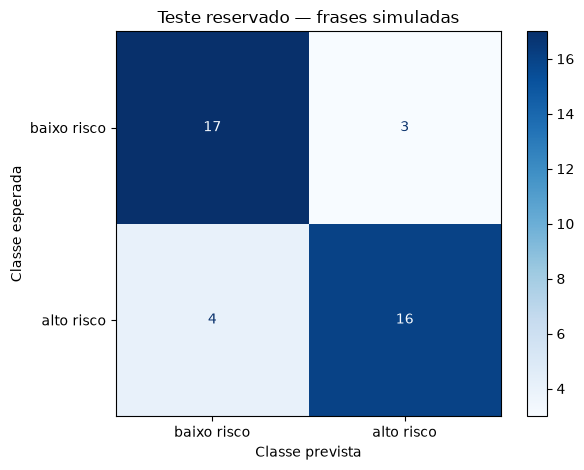

,frase,situacao,grupo,predicao,acerto
140,Enquanto preparava café senti o tórax comprimi...,alto risco,A51,alto risco,True
141,Na cozinha veio um aperto no peito com fraquez...,alto risco,A51,alto risco,True
142,A pressão no peito já dura quarenta minutos e ...,alto risco,A52,alto risco,True
143,Estou muito pálido e o peso no tórax continua ...,alto risco,A52,alto risco,True
144,Não sinto dor nas costas mas mal consigo respi...,alto risco,A53,baixo risco,False
145,As costas não incomodam; a respiração está mui...,alto risco,A53,alto risco,True
146,Minha garganta arranha um pouco mas agora surg...,alto risco,A54,alto risco,True
147,Além da rouquidão leve apareceu pressão toráci...,alto risco,A54,alto risco,True
148,Meu coração começou a correr e senti o chão su...,alto risco,A55,alto risco,True
149,Após batidas rápidas no peito apaguei e acorde...,alto risco,A55,alto risco,True


Erros a examinar:


,frase,situacao,grupo,predicao,acerto
144,Não sinto dor nas costas mas mal consigo respi...,alto risco,A53,baixo risco,False
152,Não tenho febre nem tosse mas a falta de ar é ...,alto risco,A57,baixo risco,False
153,Sem tosse ou febre; estou tão sem fôlego que p...,alto risco,A57,baixo risco,False
154,Tenho dificuldade para puxar o ar e estou com ...,alto risco,A58,baixo risco,False
226,Meu peito não aperta e não estou suando frio; ...,baixo risco,B54,alto risco,False
227,A nuca ficou irritada pela etiqueta sem pressã...,baixo risco,B54,alto risco,False
229,Tirei a meia e a marca desapareceu; minhas per...,baixo risco,B55,alto risco,False


,modelo,acuracia,recall_alto_risco,f1_macro,falsos_negativos,falsos_positivos
0,original_64_treino,0.700,0.75,0.699248,5,7
1,revisado_184_treino,0.825,0.80,0.824891,4,3


1928

In [5]:
predicoes = modelo.predict(teste.frase)
dummy = DummyClassifier(strategy="most_frequent").fit(treino[["palavras"]], treino.situacao)
baseline = accuracy_score(teste.situacao, dummy.predict(teste[["palavras"]]))
relatorio = classification_report(teste.situacao, predicoes, labels=CLASSES,
                                  output_dict=True, zero_division=0)
display(pd.DataFrame(relatorio).T)
print("Acurácia do baseline:", baseline)
matriz = confusion_matrix(teste.situacao, predicoes, labels=CLASSES)
ConfusionMatrixDisplay(matriz, display_labels=CLASSES).plot(cmap="Blues")
plt.title("Teste reservado — frases simuladas")
plt.xlabel("Classe prevista")
plt.ylabel("Classe esperada")
plt.tight_layout()
plt.savefig(SAIDA / "matriz_confusao.png", dpi=160)
plt.show()
resultados = teste[["frase", "situacao", "grupo"]].copy()
resultados["predicao"] = predicoes
resultados["acerto"] = resultados.situacao == resultados.predicao
resultados.to_csv(SAIDA / "predicoes_teste.csv", index=False)
display(resultados)
print("Erros a examinar:")
display(resultados[~resultados.acerto])
metricas = {"seed": SEED, "n_treino": len(treino), "n_teste": len(teste),
            "grupos_treino": treino.grupo.nunique(), "grupos_teste": teste.grupo.nunique(),
            "baseline_acuracia": baseline, "relatorio": relatorio,
            "matriz_confusao": matriz.tolist(),
            "cv_acuracia": cv_resultados["test_acuracia"].tolist(),
            "cv_f1_macro": cv_resultados["test_f1_macro"].tolist(),
            "sha256_dataset": hashlib.sha256((RAIZ / "fase2/data/frases_risco.csv").read_bytes()).hexdigest(),
            "python": platform.python_version(), "sklearn": sklearn.__version__,
            "numpy": np.__version__, "pandas": pd.__version__}
(SAIDA / "metricas.json").write_text(json.dumps(metricas, ensure_ascii=False, indent=2), encoding="utf-8")
comparacao = []
for nome, estimador in [("original_64_treino", modelo_anterior), ("revisado_184_treino", modelo)]:
    previsto = estimador.predict(teste.frase)
    r = classification_report(teste.situacao, previsto, output_dict=True, zero_division=0)
    m = confusion_matrix(teste.situacao, previsto, labels=CLASSES)
    comparacao.append({"modelo": nome, "acuracia": r["accuracy"],
        "recall_alto_risco": r["alto risco"]["recall"], "f1_macro": r["macro avg"]["f1-score"],
        "falsos_negativos": int(m[1, 0]), "falsos_positivos": int(m[0, 1])})
display(pd.DataFrame(comparacao))
pd.DataFrame(comparacao).to_csv(SAIDA / "comparacao_modelos.csv", index=False)
regressao = regressao.copy()
regressao["predicao"] = modelo.predict(regressao.frase)
regressao["acerto"] = regressao.situacao == regressao.predicao
regressao.to_csv(SAIDA / "predicoes_regressao.csv", index=False)
metricas.update({"n_regressao": len(regressao), "melhores_parametros": busca.best_params_,
    "comparacao_mesmo_teste": comparacao,
    "regressao_acuracia": float(regressao.acerto.mean()),
    "sha256_particoes": hashlib.sha256((RAIZ / "fase2/data/particoes.csv").read_bytes()).hexdigest()})
(SAIDA / "metricas.json").write_text(json.dumps(metricas, ensure_ascii=False, indent=2), encoding="utf-8")

## 5. Vocabulário e distorções

Coeficientes representam associações aprendidas nos exemplos. Não são fatores de risco clínico. Verificamos se termos como “leve” dominam a classe de baixo risco ou se palavras isoladas de sintomas determinam alto risco.

In [6]:
vetor = modelo.named_steps["tfidf"]
classificador = modelo.named_steps["classificador"]
termos = pd.DataFrame({"termo": vetor.get_feature_names_out(),
                      "coeficiente": classificador.coef_[0]})
print("Coeficiente positivo favorece:", classificador.classes_[1])
display(termos.sort_values("coeficiente").head(12))
display(termos.sort_values("coeficiente").tail(12))
termos.to_csv(SAIDA / "coeficientes.csv", index=False)

Coeficiente positivo favorece: baixo risco


,termo,coeficiente
1094,muito,-2.042054
1295,peito,-1.528469
1719,suor,-1.414043
824,frio,-1.231386
804,forte,-1.202640
319,comecei,-1.183218
1721,suor frio,-1.148725
1124,nao consigo,-1.067900
844,gelado,-1.046824
1623,sentado,-1.045613


,termo,coeficiente
1339,pequena,1.240813
1870,um pouco,1.248929
204,bem,1.253663
1326,pele,1.259755
1230,ou,1.275692
1160,nem,1.343107
463,depois,1.368556
949,leve,1.404368
1411,pouco,1.420036
114,apos,1.502252


## 6. Casos de regressão e sensibilidade a identidade

Os 12 desafios originais são preservados. Seus erros já foram conhecidos e motivaram a ampliação: agora são verificações de regressão, não teste independente. Não entram no treinamento nem na escolha automática dos parâmetros. Mostramos os resultados sem corrigir a saída do modelo com regras manuais.

A troca de identidade com os mesmos sintomas verifica sensibilidade textual, não comprova fairness. Faltam dados reais representativos e revisão independente dos rótulos.

In [7]:
desafios = pd.read_csv(RAIZ / "fase2/data/desafios.csv")
desafios["predicao"] = modelo.predict(desafios.frase)
desafios["acerto"] = desafios.esperado == desafios.predicao
display(desafios)
desafios.to_csv(SAIDA / "resultados_desafios.csv", index=False)
pares = pd.DataFrame({"frase": [
    "Sou homem e sinto dor no peito e suor frio.",
    "Sou mulher e sinto dor no peito e suor frio.",
    "Tenho 30 anos e sinto dor no peito e suor frio.",
    "Tenho 75 anos e sinto dor no peito e suor frio."
]})
pares["predicao"] = modelo.predict(pares.frase)
pares.to_csv(SAIDA / "sensibilidade_identidade.csv", index=False)
display(pares)

,frase,esperado,objetivo,predicao,acerto
0,Estou com pressão no peito e suor gelado desde...,alto risco,sinônimo,alto risco,True
1,Meu peito não dói mas não consigo respirar mes...,alto risco,negação com contraste,alto risco,True
2,Não tenho falta de ar nem dor no peito; só esp...,baixo risco,negação,baixo risco,True
3,Não estou com suor frio mas sinto dor no peito...,alto risco,negação com contraste,alto risco,True
4,Só sinto leve cansaço depois da caminhada e já...,baixo risco,recuperação,baixo risco,True
5,A dor no peito é leve mas começou agora junto ...,alto risco,leve não exclui alerta,alto risco,True
6,Tenho tontura intensa e meu coração está dispa...,alto risco,sinônimo,alto risco,True
7,Minha garganta arranha um pouco e respiro norm...,baixo risco,queixa leve,baixo risco,True
8,Meu tornozelo inchou e estou sem ar até quando...,alto risco,combinação,alto risco,True
9,Estou com coriza leve e não sinto dor no peito.,baixo risco,negação ao final,baixo risco,True


,frase,predicao
0,Sou homem e sinto dor no peito e suor frio.,alto risco
1,Sou mulher e sinto dor no peito e suor frio.,alto risco
2,Tenho 30 anos e sinto dor no peito e suor frio.,alto risco
3,Tenho 75 anos e sinto dor no peito e suor frio.,alto risco


## 7. Interpretação da revisão

As tabelas anteriores mostram a comparação entre as versões no mesmo teste, os falsos positivos e negativos e os casos de regressão. A ampliação melhora a cobertura de exemplos, mas não permite afirmar de antemão que a acurácia aumentará. A discussão dos resultados executados está em [avaliacao.md](../docs/avaliacao.md).

## 8. Relação com o feedback da Fase 1

Quantificamos classes e grupos, preservamos os testes conhecidos como regressão e evitamos ajustar parâmetros no teste reservado. Assim como o alvo artificial da Fase 1, os rótulos textuais refletem decisões da construção da simulação. Métricas altas não demonstram conhecimento clínico. Mais exemplos da mesma autoria não substituem revisão especializada nem dados externos.

## Fontes

- [Scikit-learn — prevenção de vazamento](https://scikit-learn.org/stable/common_pitfalls.html)
- [Scikit-learn — GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)
- [Ministério da Saúde — infarto](https://www.gov.br/saude/pt-br/assuntos/saude-de-a-a-z/i/infarto)
- [Fontes e critérios da base](../docs/dados_e_limites.md)

Nenhuma frase é prontuário ou transcrição de paciente. O sistema é um exercício acadêmico.